# Adaptive memory testing analysis

This notebook reads the simulated PsyNet export directly from `../simulated_data.zip` and checks whether the adaptive policy stores the required metadata and learns different trajectories for synthetic participants with different abilities.

In [1]:
from pathlib import Path
from zipfile import ZipFile
import json
import pandas as pd

zip_path = Path('../simulated_data.zip')
with ZipFile(zip_path) as zf:
    with zf.open('simulated_data/regular/data/MemoryTrial.csv') as f:
        trials = pd.read_csv(f)
    with zf.open('simulated_data/regular/data/Bot.csv') as f:
        bots = pd.read_csv(f)

trials = trials.sort_values(['participant_id', 'id']).copy()
trials['trial_index'] = trials.groupby('participant_id').cumcount() + 1
for column in ['posterior_summary', 'acquisition_values', 'model']:
    trials[column] = trials[column].apply(json.loads)
for name in ['mu_mean', 'alpha_mean', 'r_mean', 'mu_sd', 'alpha_sd', 'r_sd']:
    trials[name] = trials['posterior_summary'].apply(lambda value: value[name])
trials['correct'] = trials['score'].astype(int)
bots = bots[['id', 'memory_ability']].rename(columns={'id': 'participant_id'})
trials = trials.merge(bots, on='participant_id', how='left')
trials.shape

(60, 61)

In [2]:
overall = pd.DataFrame({
    'metric': ['participants', 'trials', 'unique synthetic abilities', 'min selected length', 'max selected length', 'mean correctness', 'metadata rows with joint parameters'],
    'value': [trials['participant_id'].nunique(), len(trials), ', '.join(str(x) for x in sorted(trials['memory_ability'].unique())), int(trials['length'].min()), int(trials['length'].max()), round(float(trials['correct'].mean()), 3), int(trials['model'].apply(lambda value: value['updated_parameters'] == ['mu', 'alpha', 'r_i']).sum())],
})
overall

metric,value
participants,6
trials,60
unique synthetic abilities,"0.45, 0.7, 1.0, 1.4, 2.0, 3.0"
min selected length,2
max selected length,20
mean correctness,0.367
metadata rows with joint parameters,60


In [3]:
participant_summary = (
    trials.groupby(['participant_id', 'memory_ability'])
    .agg(mean_length=('length', 'mean'), final_length=('length', 'last'), accuracy=('correct', 'mean'), final_r_mean=('r_mean', 'last'), final_mu_mean=('mu_mean', 'last'), final_alpha_mean=('alpha_mean', 'last'))
    .reset_index().sort_values('memory_ability').round(3)
)
participant_summary

participant_id,memory_ability,mean_length,final_length,accuracy,final_r_mean,final_mu_mean,final_alpha_mean
1,0.45,8.1,10,0.3,0.895,1.062,2.160
2,0.70,8.1,12,0.4,1.101,1.169,2.155
3,1.00,13.3,14,0.3,1.258,1.244,2.154
4,1.40,10.1,11,0.3,1.050,1.144,2.164
5,2.00,9.1,11,0.4,0.978,1.107,2.165
6,3.00,9.8,15,0.5,1.330,1.277,2.147


In [4]:
trial_summary = trials.groupby('trial_index').agg(mean_length=('length', 'mean'), mean_accuracy=('correct', 'mean'), mean_r=('r_mean', 'mean')).reset_index().round(3)
trial_summary

trial_index,mean_length,mean_accuracy,mean_r
1,6.000,0.167,0.770
2,5.667,0.667,0.658
3,7.500,0.500,0.873
4,9.500,0.667,0.979
5,11.667,0.000,1.199
6,10.667,0.167,1.045
7,10.333,0.667,0.990
8,12.000,0.167,1.135
9,12.000,0.333,1.105
10,12.167,0.333,1.102


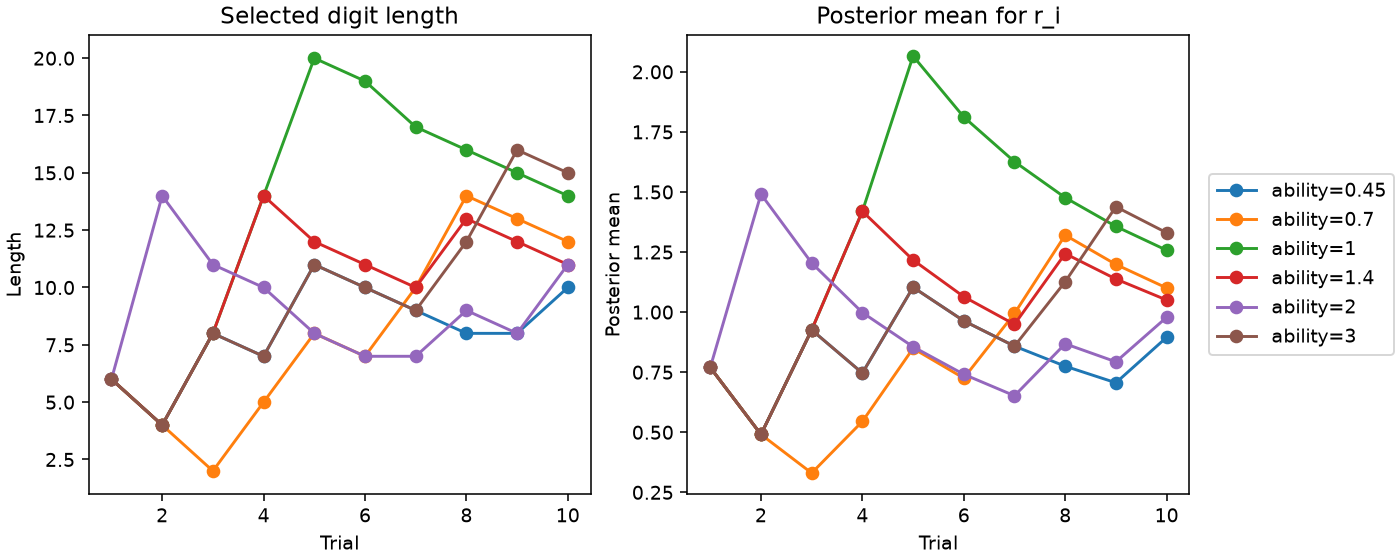

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)
for ability, group in trials.sort_values(['memory_ability', 'trial_index']).groupby('memory_ability'):
    by_trial = group.groupby('trial_index').mean(numeric_only=True)
    axes[0].plot(by_trial.index, by_trial['length'], marker='o', label=f'ability={ability:g}')
    axes[1].plot(by_trial.index, by_trial['r_mean'], marker='o', label=f'ability={ability:g}')
axes[0].set(title='Selected digit length', xlabel='Trial', ylabel='Length', ylim=(1, 21))
axes[1].set(title='Posterior mean for r_i', xlabel='Trial', ylabel='Posterior mean')
axes[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5));

## Interpretation

The simulated export contains 60 trials from 6 bots with abilities [0.45, 0.7, 1.0, 1.4, 2.0, 3.0]. All 60 trial metadata rows record joint updates for mu, alpha, and r_i. The lowest-ability bot trends toward short strings, while higher-ability bots receive longer strings and higher posterior r_i estimates.